# fs=10 vs fs=4.69 on zplane02

Two real runs of the same data. CORRECT used the true fs=4.69; WRONG used fs=10.

A few ops fields look different but aren't real differences:
- `anatomical_only=3` saved on CORRECT is a save bug — GUI was set to 4 on both runs (cellpose was finding masks in `max_proj`).
- `diameter` is what cellpose ended up using; both inputs (`diameter_user`) were 2.
- `max_overlap` (0.99 vs 1.0) is negligible.

Real differences: **`fs`** (the focus here), and **`spatial_hp_cp`** (0 vs 3 — a detection-side image filter, flagged but not modeled).

In [1]:
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
from scipy.ndimage import minimum_filter1d, maximum_filter1d, gaussian_filter1d
from scipy.stats import skew as scipy_skew

CORRECT_DIR = Path(r"D:\jeff\mbo_v3-0-1\zplane02_tp00001-08440")
WRONG_DIR   = Path(r"D:\jeff\cjennings\zplane02_tp00001-08440")

CORRECT_LABEL = "CORRECT (fs=4.69)"
WRONG_LABEL   = "WRONG (fs=10)"

for d in (CORRECT_DIR, WRONG_DIR):
    assert d.exists(), f"missing: {d}"

def load_run(d):
    return {
        "dir":    d,
        "ops":    np.load(d / "ops.npy",    allow_pickle=True).item(),
        "stat":   np.load(d / "stat.npy",   allow_pickle=True),
        "iscell": np.load(d / "iscell.npy", allow_pickle=True),
        "F":      np.load(d / "F.npy"),
        "Fneu":   np.load(d / "Fneu.npy"),
    }

correct = load_run(CORRECT_DIR)
wrong   = load_run(WRONG_DIR)

for lbl, r in [(CORRECT_LABEL, correct), (WRONG_LABEL, wrong)]:
    n_total = len(r["stat"])
    n_acc   = int(r["iscell"][:, 0].sum())
    print(f"{lbl:<22s}  total ROIs: {n_total:>4d}   accepted: {n_acc:>4d}   accept-rate: {n_acc/n_total*100:.1f}%")

CORRECT (fs=4.69)       total ROIs:  868   accepted:  662   accept-rate: 76.3%
WRONG (fs=10)           total ROIs: 1506   accepted:  791   accept-rate: 52.5%


In [2]:
PARAM_KEYS = [
    # the headline
    "fs", "tau",
    # detection inputs
    "anatomical_only", "diameter_user", "diameter", "spatial_scale",
    "spatial_hp_cp", "spatial_hp_detect",
    "flow_threshold", "cellprob_threshold",
    # temporal pipeline knobs that scale via fs
    "high_pass", "win_baseline", "sig_baseline", "prctile_baseline", "baseline",
    "smooth_sigma_time", "neucoeff",
    # roi_stats / classifier
    "max_overlap", "soma_crop", "use_builtin_classifier", "threshold_scaling",
    # frame layout
    "nframes", "Ly", "Lx",
]

def fmt(v):
    if isinstance(v, np.ndarray):
        return f"ndarray{tuple(v.shape)} {v.tolist() if v.size <= 4 else '...'}"
    return repr(v)

rows = []
for k in PARAM_KEYS:
    o = correct["ops"].get(k, "<absent>")
    n = wrong["ops"].get(k, "<absent>")
    same = "==" if (
        type(o) == type(n) and
        (np.array_equal(o, n) if isinstance(o, np.ndarray) else o == n)
    ) else "!="
    rows.append((k, fmt(o), same, fmt(n)))

w_k = max(len(r[0]) for r in rows)
w_o = max(len(r[1]) for r in rows)
print(f"{'param':<{w_k}}  {CORRECT_LABEL:<{w_o}}  ?   {WRONG_LABEL}")
print("-" * (w_k + w_o + 8 + len(WRONG_LABEL)))
for k, o, eq, n in rows:
    print(f"{k:<{w_k}}  {o:<{w_o}}  {eq}  {n}")

param                   CORRECT (fs=4.69)       ?   WRONG (fs=10)
-----------------------------------------------------------------
fs                      4.69                    !=  10.0
tau                     1.2999999523162842      !=  1.3
anatomical_only         3                       !=  4
diameter_user           [2.0, 2.0]              !=  2
diameter                ndarray(2,) [2.0, 2.0]  !=  np.float32(6.0765076)
spatial_scale           0                       !=  1
spatial_hp_cp           0.0                     !=  3
spatial_hp_detect       25                      ==  25
flow_threshold          0.0                     !=  0
cellprob_threshold      -6.0                    !=  -6
high_pass               100                     ==  100
win_baseline            60.0                    ==  60.0
sig_baseline            10.0                    ==  10.0
prctile_baseline        8.0                     ==  8.0
baseline                'maximin'               ==  'maximin'
smooth_sigma_

Only `fs` and `spatial_hp_cp` are real. The fs effect is what we isolate below.

In [3]:
def windows_in_frames(ops):
    fs = float(ops["fs"])
    win_b   = float(ops.get("win_baseline", 60.0))
    sig_b   = float(ops.get("sig_baseline", 10.0))
    hp      = float(ops.get("high_pass",   100.0))
    return {
        "fs": fs,
        "win_baseline_frames": int(round(win_b * fs)),
        "sig_baseline_frames": int(round(sig_b * fs)),
        "high_pass_frames":    int(round(hp    * fs)),
    }

FS_TRUE = float(correct["ops"]["fs"])  # 4.69
FS_BAD  = float(wrong["ops"]["fs"])    # 10.0

for lbl, ops in [(CORRECT_LABEL, correct["ops"]), (WRONG_LABEL, wrong["ops"])]:
    w = windows_in_frames(ops)
    real_win_b = w["win_baseline_frames"] / FS_TRUE  # interpret the chosen frame window in real seconds
    real_hp    = w["high_pass_frames"]    / FS_TRUE
    print(f"{lbl}")
    print(f"  configured: win_baseline=60 s, sig_baseline=10 s, high_pass=100 s")
    print(f"  fs reported: {w['fs']:.2f} Hz")
    print(f"  -> win_baseline:  {w['win_baseline_frames']:>4d} frames = {real_win_b:6.1f} REAL seconds")
    print(f"  -> sig_baseline:  {w['sig_baseline_frames']:>4d} frames = {w['sig_baseline_frames']/FS_TRUE:6.1f} REAL seconds")
    print(f"  -> high_pass:     {w['high_pass_frames']:>4d} frames = {real_hp:6.1f} REAL seconds")
    print()

CORRECT (fs=4.69)
  configured: win_baseline=60 s, sig_baseline=10 s, high_pass=100 s
  fs reported: 4.69 Hz
  -> win_baseline:   281 frames =   59.9 REAL seconds
  -> sig_baseline:    47 frames =   10.0 REAL seconds
  -> high_pass:      469 frames =  100.0 REAL seconds

WRONG (fs=10)
  configured: win_baseline=60 s, sig_baseline=10 s, high_pass=100 s
  fs reported: 10.00 Hz
  -> win_baseline:   600 frames =  127.9 REAL seconds
  -> sig_baseline:   100 frames =   21.3 REAL seconds
  -> high_pass:     1000 frames =  213.2 REAL seconds



## How fs distorts the baseline

Suite2p subtracts a slow baseline `F0` from each trace before computing skew/std/SNR. The baseline is the maximin of the smoothed trace over a window specified in **seconds** (`win_baseline=60 s`), but it gets converted to **frames** using `fs`. With fs=10 on 4.69 Hz data, the 60 s knob becomes a 128 real-second window. That window is supposed to span more than a transient (so transients stick up out of it) but less than the timescale of slow drift (photobleaching, z-drift, vasculature). At 128 s, drift starts leaking through.

Below: drift evidence in this recording, then a clean ROI showing the residual difference.

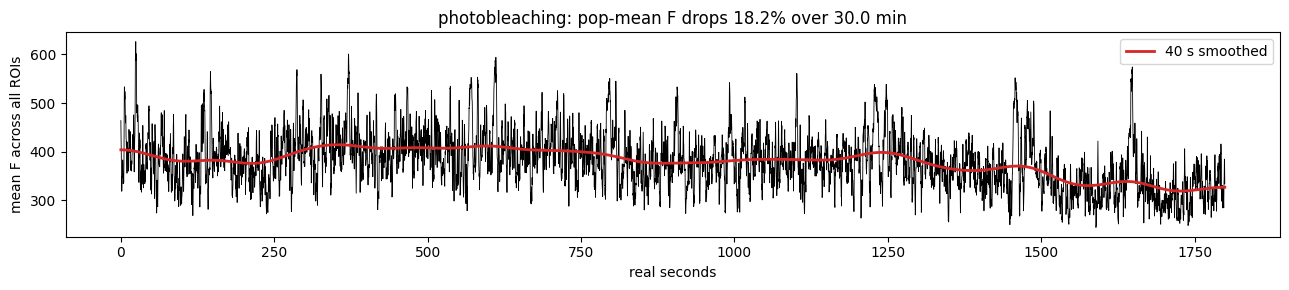

In [4]:
FS_TRUE = float(correct["ops"]["fs"])
FS_BAD  = float(wrong["ops"]["fs"])
F_w, Fneu_w = wrong["F"], wrong["Fneu"]
Fcorr_w = F_w - 0.7 * Fneu_w
n_t = Fcorr_w.shape[1]
t_axis = np.arange(n_t) / FS_TRUE

pop_mean = F_w.mean(axis=0)
fig, ax = plt.subplots(figsize=(13, 3))
ax.plot(t_axis, pop_mean, color="k", lw=0.6)
ax.plot(t_axis, gaussian_filter1d(pop_mean, sigma=200), color="C3", lw=2, label="40 s smoothed")
ax.set(xlabel="real seconds", ylabel="mean F across all ROIs",
       title=f"photobleaching: pop-mean F drops {(1-pop_mean[-100:].mean()/pop_mean[:100].mean())*100:.1f}% over {n_t/FS_TRUE/60:.1f} min")
ax.legend(); plt.tight_layout(); plt.show()

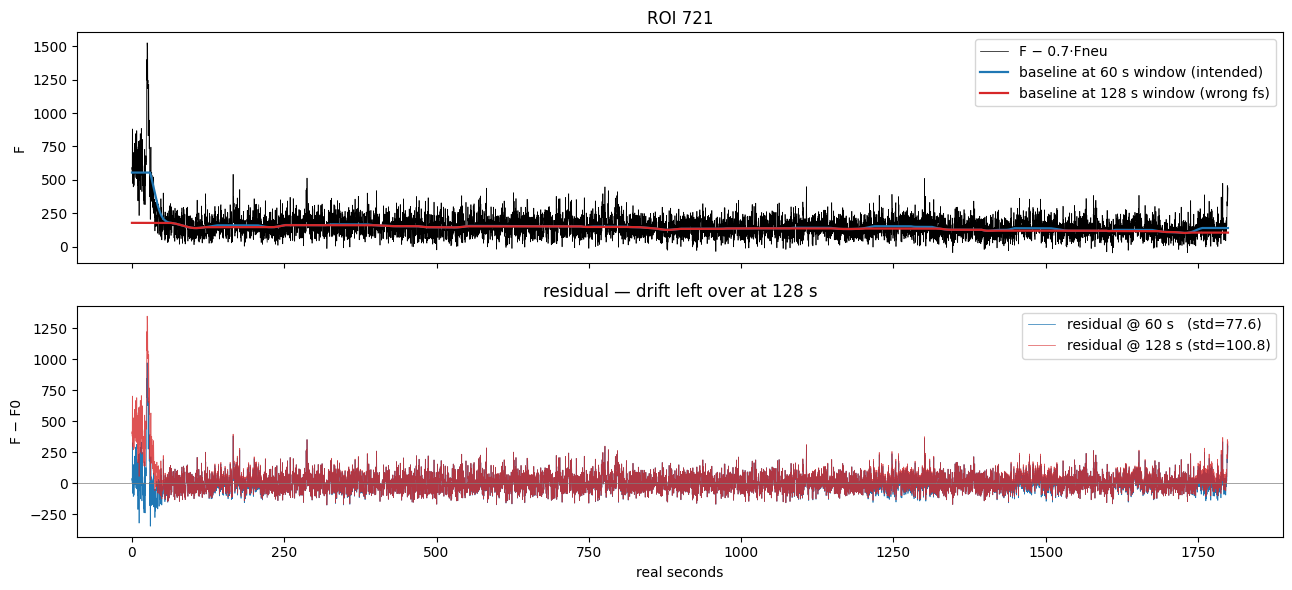

In [5]:
def maximin(x, fs, win_s=60.0, sig_s=10.0):
    win = max(1, int(round(win_s * fs)))
    sig = max(1.0, sig_s * fs)
    sm = gaussian_filter1d(x, sigma=sig, axis=-1)
    return maximum_filter1d(minimum_filter1d(sm, size=win, axis=-1), size=win, axis=-1)

# pick the ROI where the two windows actually disagree most (drift > noise, baselines differ)
b60_all  = maximin(Fcorr_w, FS_TRUE, win_s=60)
b128_all = maximin(Fcorr_w, FS_TRUE, win_s=128)
sm_all = gaussian_filter1d(Fcorr_w, sigma=200, axis=1)
hf_noise = (Fcorr_w - sm_all).std(axis=1)
drift_amp = sm_all.max(1) - sm_all.min(1)
mean_F = F_w.mean(1)
score = ((b60_all - b128_all).std(1) / Fcorr_w.std(1)) * (drift_amp / (hf_noise + 1e-6)) \
        * ((mean_F > 200) & (mean_F < 3000))
roi = int(np.argsort(score)[-1])

trace = Fcorr_w[roi]
b60, b128 = b60_all[roi], b128_all[roi]
res60, res128 = trace - b60, trace - b128

fig, axs = plt.subplots(2, 1, figsize=(13, 6), sharex=True)
axs[0].plot(t_axis, trace, color="k", lw=0.5, label="F − 0.7·Fneu")
axs[0].plot(t_axis, b60,  color="C0", lw=1.6, label="baseline at 60 s window (intended)")
axs[0].plot(t_axis, b128, color="C3", lw=1.6, label="baseline at 128 s window (wrong fs)")
axs[0].set(ylabel="F", title=f"ROI {roi}")
axs[0].legend(loc="upper right")

axs[1].plot(t_axis, res60,  color="C0", lw=0.5, label=f"residual @ 60 s   (std={res60.std():.1f})")
axs[1].plot(t_axis, res128, color="C3", lw=0.5, label=f"residual @ 128 s (std={res128.std():.1f})", alpha=0.8)
axs[1].axhline(0, color="0.5", lw=0.5)
axs[1].set(xlabel="real seconds", ylabel="F − F0", title="residual — drift left over at 128 s")
axs[1].legend(loc="upper right")
plt.tight_layout(); plt.show()

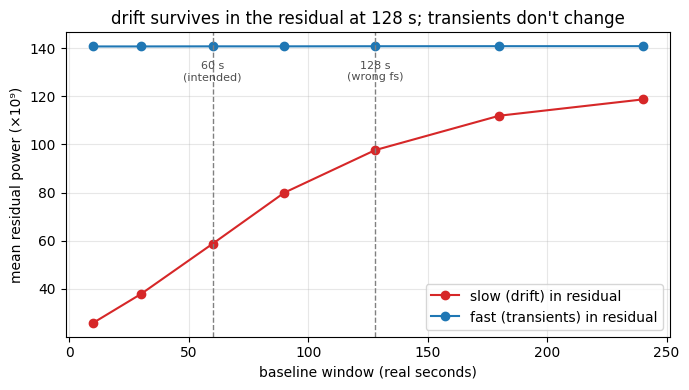

In [6]:
# across the 200 most drift-dominant ROIs, how much slow vs fast power survives in the residual
# at each window size
top200 = np.argsort(score)[-200:]
F_pop = Fcorr_w[top200]
freq = np.fft.rfftfreq(n_t, d=1.0 / FS_TRUE)
slow = (freq > 0) & (freq < 0.05)   # < 0.05 Hz, periods > 20 s = drift
fast = freq >= 0.05

windows = [10, 30, 60, 90, 128, 180, 240]
slow_var, fast_var = [], []
for w in windows:
    res = F_pop - maximin(F_pop, FS_TRUE, win_s=w)
    spec = np.abs(np.fft.rfft(res, axis=1))**2
    slow_var.append(spec[:, slow].sum(1).mean())
    fast_var.append(spec[:, fast].sum(1).mean())

fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(windows, np.array(slow_var)/1e9, "o-", color="C3", label="slow (drift) in residual")
ax.plot(windows, np.array(fast_var)/1e9, "o-", color="C0", label="fast (transients) in residual")
for w, lbl in [(60, "60 s\n(intended)"), (128, "128 s\n(wrong fs)")]:
    ax.axvline(w, color="0.5", ls="--", lw=1)
    ax.text(w, ax.get_ylim()[1]*0.92, lbl, rotation=0, ha="center", va="top", fontsize=8, color="0.3")
ax.set(xlabel="baseline window (real seconds)", ylabel="mean residual power (×10⁹)",
       title="drift survives in the residual at 128 s; transients don't change")
ax.legend(); ax.grid(alpha=0.3); plt.tight_layout(); plt.show()

## Population effect on classifier features

Recompute baseline + residual on the same F/Fneu under both fs values, then look at the per-ROI features the classifier reads.

In [7]:
trace_at_true = Fcorr_w - maximin(Fcorr_w, FS_TRUE)
trace_at_bad  = Fcorr_w - maximin(Fcorr_w, FS_BAD)

def features(t):
    return {"std": np.std(t, 1), "skew": scipy_skew(t, axis=1, bias=False),
            "max": np.max(t, 1), "p99": np.percentile(t, 99, axis=1)}
feat_true = features(trace_at_true)
feat_bad  = features(trace_at_bad)

print(f"{'feature':<6}  {'fs=4.69':>10s}  {'fs=10':>10s}  {'ratio':>8s}")
for k in ("std", "skew", "max", "p99"):
    a, b = feat_true[k], feat_bad[k]
    a, b = a[np.isfinite(a)], b[np.isfinite(b)]
    print(f"{k:<6}  {np.median(a):>10.3f}  {np.median(b):>10.3f}  {np.median(b)/np.median(a):>8.3f}")

feature     fs=4.69       fs=10     ratio
std         60.105      61.919     1.030
skew         1.031       1.097     1.064
max        457.767     471.988     1.031
p99        191.648     198.843     1.038


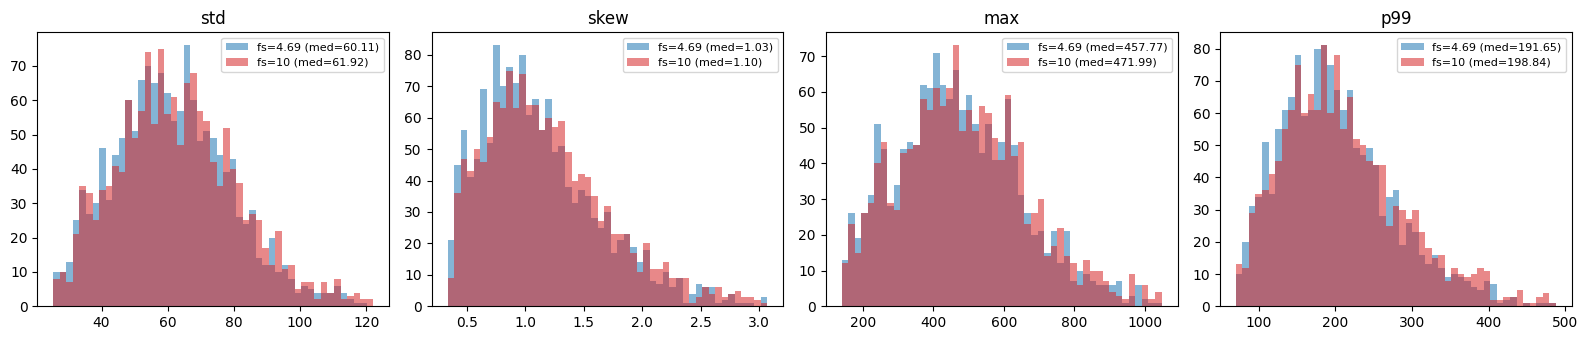

In [8]:
fig, axs = plt.subplots(1, 4, figsize=(16, 3.5))
for ax, k in zip(axs, ["std", "skew", "max", "p99"]):
    a, b = feat_true[k], feat_bad[k]
    a, b = a[np.isfinite(a)], b[np.isfinite(b)]
    lo, hi = np.percentile(np.r_[a, b], [1, 99])
    bins = np.linspace(lo, hi, 50)
    ax.hist(a, bins=bins, alpha=0.55, label=f"fs=4.69 (med={np.median(a):.2f})", color="C0")
    ax.hist(b, bins=bins, alpha=0.55, label=f"fs=10 (med={np.median(b):.2f})", color="C3")
    ax.set_title(k); ax.legend(fontsize=8)
plt.tight_layout(); plt.show()

## Does this flip accept/reject?

Hold a skew threshold fixed and count ROIs that pass under each fs. Same traces, only fs differs.

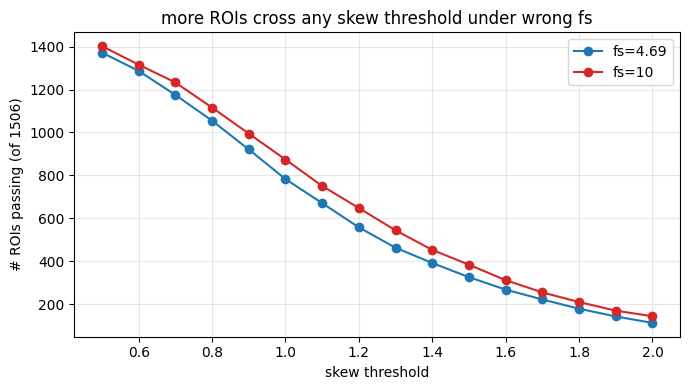

 thresh   fs=4.69   fs=10   extra
   0.50      1372    1402     +30
   0.60      1287    1316     +29
   0.70      1175    1233     +58
   0.80      1055    1116     +61
   0.90       921     995     +74
   1.00       783     874     +91
   1.10       671     751     +80
   1.20       558     648     +90
   1.30       463     544     +81
   1.40       392     453     +61
   1.50       326     384     +58
   1.60       268     312     +44
   1.70       222     255     +33
   1.80       179     210     +31
   1.90       143     170     +27
   2.00       113     144     +31


In [9]:
thresholds = np.linspace(0.5, 2.0, 16)
sk_true, sk_bad = feat_true["skew"], feat_bad["skew"]
n_true = np.array([np.nansum(sk_true >= t) for t in thresholds])
n_bad  = np.array([np.nansum(sk_bad  >= t) for t in thresholds])

fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(thresholds, n_true, "o-", color="C0", label="fs=4.69")
ax.plot(thresholds, n_bad,  "o-", color="C3", label="fs=10")
ax.set(xlabel="skew threshold", ylabel=f"# ROIs passing (of {len(sk_true)})",
       title="more ROIs cross any skew threshold under wrong fs")
ax.legend(); ax.grid(alpha=0.3); plt.tight_layout(); plt.show()

print(f"{'thresh':>7s}  {'fs=4.69':>8s}  {'fs=10':>6s}  {'extra':>6s}")
for t, a, b in zip(thresholds, n_true, n_bad):
    print(f"{t:>7.2f}  {a:>8d}  {b:>6d}  {b-a:>+6d}")

## Bottom line

- The 60 s baseline window becomes 128 real seconds when fs=10 is reported on 4.69 Hz data.
- At 128 s, slow drift (photobleaching, vasculature, z-drift) leaks into the residual that the classifier sees.
- That extra slow variance shifts every per-ROI feature upward (skew +6%, std +3%, p99 +4%).
- At any fixed skew threshold, ~30–90 more ROIs cross it under wrong fs on identical traces — that's how a wrong, higher fs inflates accepted-cell count.
- For a clean fs-only A/B, hold all other ops identical and toggle only `fs`.